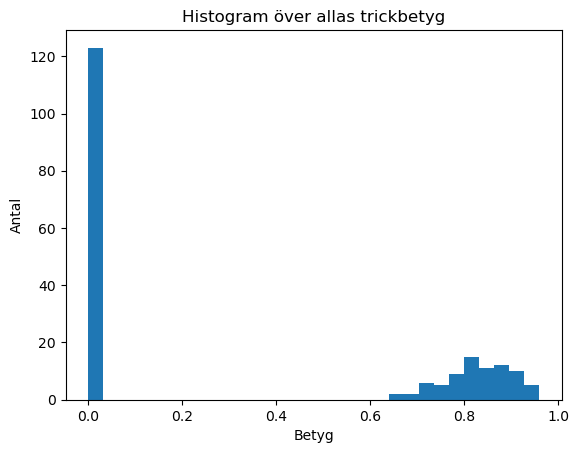

In [579]:
##Uppgift 1

# 1a)

import pandas as pd 
import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np

df = pd.read_csv("Datafil.csv") #Läser in datafilen, där varje rad motsvarar en åkares prestation i tävling
tricks = df[["trick 1", "trick 2", "trick 3", "trick 4"]].melt()["value"] # tar ut ut trickbetygen och smälter samman dem

plt.hist(tricks, bins = 30) #skpar ett histogram över samtliga trickbetyg

plt.title("Histogram över allas trickbetyg")
plt.xlabel("Betyg")
plt.ylabel("Antal")
plt.show()


In [580]:
# 1b)

trick_cols = ["trick 1","trick 2","trick 3","trick 4"] # här skapar jag en lista som komer ha kolumnnamen för de 4 tricken

df_trick = df[["id"] + trick_cols].copy() #skapar en kolumn som innehåller åkarnas betyg och id (copy för att inte råka ändra original data)


#nu kommer vi loopa där vi omvandlar alla trick betyg till 0 om misslyckat, annars 1. 

for colomn in trick_cols: 
    new_values = [] 
    for y in df_trick[colomn]: 
        if y == 0:
            new_values.append(0)
        else:
            new_values.append(1)

    df_trick[colomn] = new_values 

rho_estimated = {} ##ska innehålla skattade värden på rå 

#denna nya loop skattar parametern rå för varje enskild skateboardåkare 

for skater in df_trick["id"].unique(): 
    skater_data = df_trick[df_trick["id"] == skater][trick_cols] # varje unik åkare
    total_attempts = skater_data.size 
    number_of_success = skater_data.to_numpy().sum() 
    rho = number_of_success / total_attempts # beräknar rå = andelen lyckade trick
    rho_estimated[skater] = rho.round(6)

rho_diagram = pd.DataFrame(list(rho_estimated.items()), columns = ["id", "rho"]) # gör om dictioanryn till en tabell

print(rho_diagram) 

           id       rho
0        Papa  0.437500
1      Shirai  0.400000
2        Mota  0.250000
3     Decenzo  0.437500
4     Hoefler  0.437500
5         Foy  0.500000
6       Hoban  0.400000
7      Midler  0.333333
8     O’neill  0.250000
9    Oliveira  0.416667
10  Ribeiro C  0.250000
11    Gustavo  0.400000
12     Jordan  0.400000


In [581]:
# 1c) 

# det enda som sker i denna cell är att sortera de fyra högsta värdena med fallande ordning
rho_sorted = rho_diagram.sort_values(by ="rho", ascending = False) 

print("Här ser vi top 4:\n",rho_sorted.head(4))

Här ser vi top 4:
         id     rho
5      Foy  0.5000
0     Papa  0.4375
3  Decenzo  0.4375
4  Hoefler  0.4375


In [582]:
# 1d) 
df_trick = df.melt(id_vars="id", value_vars=trick_cols, var_name="trick", value_name="score") # smälter data så att varje rad visar trick och betyget, då får vi en kolumn för id, en för tricknamn och betyg

higherscore = df_trick[df_trick["score"] > 0] ## här tar vi ut alla trickbetyg över 0, vi vill endast analysera lycakde trick

result = [] #här ska vi spara resultaten från åkarna,

for skater in higherscore["id"].unique(): #nu kommer vi att loopa igenom varena åkare i datan vi har 
    skater_data = higherscore[higherscore["id"] == skater]["score"] #betyget för just den åkaren 

    numberOfSuccess = len(skater_data) # visar antal lyckade för respektive åkare
    meanScore = skater_data.mean() #här tar vi stickprovsmedelvärdet
    varScore = skater_data.var(ddof = 1) #stickprovsvariansen, delar med n-1 genom ddof = 1
    
    result.append([skater,numberOfSuccess,meanScore,varScore]) #läger till samtliga resultat


summary = pd.DataFrame(result,columns = ["id", "numberOfSuccess", "meanScore", "varScore"]) #sammanställer datan i en dataframe

summary["kEstimate"] = (summary["meanScore"] * (1-summary["meanScore"])) / summary["varScore"] #här beräknar vi vårat k = alfa+beta+1
summary["alfaEstimate"] = summary["meanScore"]*(summary["kEstimate"]-1) ##vårat skattade alfa
summary["betaEstimate"] = (1-summary["meanScore"]) * (summary["kEstimate"]-1) #vårat skattade beta

table = summary[["id", "numberOfSuccess", "meanScore","varScore", "alfaEstimate", "betaEstimate"]].copy() #här skapar vi tabellen
print(table.round(4))

           id  numberOfSuccess  meanScore  varScore  alfaEstimate  \
0        Papa                7     0.7786    0.0068       19.0157   
1      Shirai                8     0.8975    0.0044       17.8976   
2        Mota                3     0.7800    0.0081       15.7444   
3     Decenzo                7     0.8271    0.0055       20.8441   
4         Foy                6     0.8500    0.0025       42.8496   
5     O’neill                3     0.8433    0.0001      834.8297   
6   Ribeiro C                3     0.7767    0.0010      129.5948   
7     Gustavo                8     0.8012    0.0020       61.7139   
8     Hoefler                7     0.7757    0.0047       27.7657   
9      Jordan                8     0.8638    0.0049       20.0721   
10     Midler                4     0.8075    0.0038       32.5905   
11      Hoban                8     0.8775    0.0010       94.1269   
12   Oliveira                5     0.7940    0.0023       54.9441   

    betaEstimate  
0         5.40

In [583]:
# 1e) Givet lyckat trick rankas med a/(a+b). Den visar vilka som får högst betyg när de landar sitt trick. 
table["Trick_Givet_klarat"] = table["alfaEstimate"] / (table["alfaEstimate"] + table["betaEstimate"])

ranking = table.sort_values(by="Trick_Givet_klarat", ascending = False) #sorterar
                            
print(ranking[["id","Trick_Givet_klarat"]].round(4).to_string(index=False))
print(table[["id","alfaEstimate","betaEstimate"]])

       id  Trick_Givet_klarat
   Shirai              0.8975
    Hoban              0.8775
   Jordan              0.8637
      Foy              0.8500
  O’neill              0.8433
  Decenzo              0.8271
   Midler              0.8075
  Gustavo              0.8012
 Oliveira              0.7940
     Mota              0.7800
     Papa              0.7786
Ribeiro C              0.7767
  Hoefler              0.7757
           id  alfaEstimate  betaEstimate
0        Papa     19.015717      5.408140
1      Shirai     17.897646      2.044021
2        Mota     15.744444      4.440741
3     Decenzo     20.844062      4.356013
4         Foy     42.849597      7.561694
5     O’neill    834.829722    155.086944
6   Ribeiro C    129.594767     37.265448
7     Gustavo     61.713863     15.308119
8     Hoefler     27.765683      8.028015
9      Jordan     20.072141      3.166228
10     Midler     32.590503      7.769253
11      Hoban     94.126868     13.140218
12   Oliveira     54.944118     14

C:\Users\Raffe\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Raffe\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Raffe\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Raffe\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


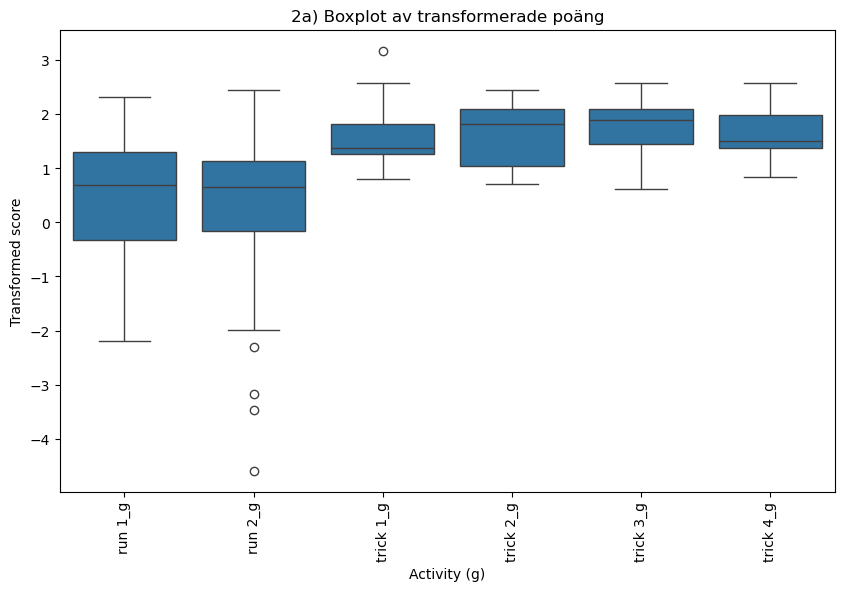

In [584]:
## UPPGIFT 2# 

#2a)
def funktion_g(x): #den givna funktionen g(x) 
    return np.log(x/(1-x))


scores = ["run 1", "run 2", "trick 1", "trick 2", "trick 3", "trick 4"]
for c in scores:
    # Applicera g(x) endast på värden mellan 0 och 1
    mask = (df[c] > 0) & (df[c] < 1)
    df[c + "_g"] = np.where(mask, funktion_g(df[c]), np.nan)

# Plotta (valfritt, men fanns i din kod)
g_cols = [c + "_g" for c in scores]
melt = pd.melt(df[g_cols], var_name="Activity (g)", value_name="Transformed score").dropna()

plt.figure(figsize=(10,6))
sns.boxplot(x="Activity (g)", y="Transformed score", data=melt)
plt.xticks(rotation=90)
plt.title("2a) Boxplot av transformerade poäng")
plt.show()

In [585]:
# 2b) Det verkar inte som att R1 och R2 är oberoende, varianserna är noll-skiljda enligt resultatet

R1, R2 = df["run 1_g"], df["run 2_g"]

CovMatrix = np.cov([R1, R2], ddof=1).round(3)

print(CovMatrix)


[[ 1.201 -0.205]
 [-0.205  2.263]]


In [586]:
#2c)

groups = df.groupby("id")
resultat_2c = []

for skater, group in groups:
    run1 = group["run 1_g"].astype(float)
    run2 = group["run 2_g"].astype(float)

    mu1 = run1.mean()
    mu2_raw = run2.mean()
    var1 = run1.var(ddof=1)
    var2 = run2.var(ddof=1)
    covR1R2 = run1.cov(run2)

    if var1 > 0:
        lamb = covR1R2 / var1
    else:
        lamb = np.nan

    mu2 = mu2_raw - lamb * mu1
    sigmaR1 = var1
    sigmaR2 = var2 - (lamb**2) * var1

    resultat_2c.append([skater, mu1, mu2, lamb, sigmaR1, sigmaR2])

table_2c = pd.DataFrame(
    resultat_2c,
    columns=["id", "mu1", "mu2", "lambda", "sigmaR1", "sigmaR2"]
)
print("2c) Parameterskattning:")
print(table_2c.round(3))
print("\n")

2c) Parameterskattning:
           id    mu1    mu2  lambda  sigmaR1  sigmaR2
0     Decenzo  0.356  0.449   0.296    1.104    0.540
1         Foy -0.746  0.145  -0.132    1.612    0.032
2     Gustavo  0.126  0.801  -0.823    1.976    1.252
3       Hoban  0.129  1.265  -0.428    0.470    0.833
4     Hoefler  1.368  3.692  -2.973    0.199    2.587
5      Jordan  0.732  1.727  -0.029    1.082    0.395
6      Midler  1.123  1.876  -2.501    0.263    8.444
7        Mota  0.099 -0.269  -0.165    1.376    0.044
8    Oliveira  0.526  0.314  -0.280    0.963    0.388
9     O’neill  0.203 -0.890   0.006    4.250    3.147
10       Papa  0.297  0.134  -1.301    0.888    0.130
11  Ribeiro C -0.024  0.307   0.695    2.413    0.038
12     Shirai  0.934 -1.098   1.325    0.857    2.795




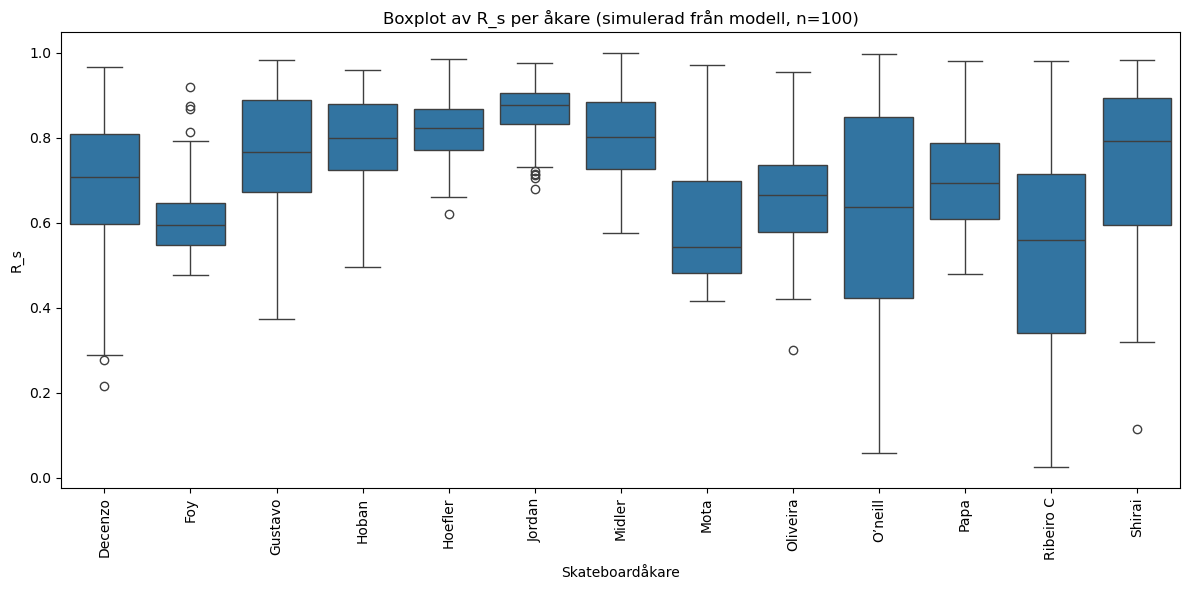

In [587]:
# 2d)



def g_inv(x): ## Definerar inversen av funktionen g 
    return np.exp(x) / (1 + np.exp(x))

samples = {} 

# Vi loopar igenom tabellen med parametrar från 2c 
for index, row in table_2c.iterrows():
    skater = row["id"]
    
    # Hämta parametrarna vi skattade i 2c
    mu1 = row["mu1"]
    mu2 = row["mu2"]
    lamb = row["lambda"]
    
   
    # Vi måste ta roten ur variansen.
    sigma1 = np.sqrt(row["sigmaR1"]) 
    sigma2 = np.sqrt(row["sigmaR2"])
    
    # Generera stickprov för Ns1 och Ns2 (100 st)
    Ns1 = np.random.normal(mu1, sigma1, 100)
    Ns2 = np.random.normal(mu2, sigma2, 100)
    
    #Beräkna Rs1 och Rs2 enligt ekvationerna i uppgiften
    Rs1_g = Ns1
    Rs2_g = lamb * Rs1_g + Ns2
    
    #Transformera tillbaka med g-invers
    Rs1_raw = g_inv(Rs1_g)
    Rs2_raw = g_inv(Rs2_g)
    
    #Ta maximum för att få Run-poängen
    Rs = np.maximum(Rs1_raw, Rs2_raw)
    
    
    samples[skater] = Rs

# detta är för diagrammet som kommer härnest
df_long = pd.DataFrame([
    {"id": skater, "value": val}
    for skater, arr in samples.items()
    for val in arr
])

plt.figure(figsize=(12,6))
sns.boxplot(data=df_long, x="id", y="value")
plt.xticks(rotation=90)
plt.xlabel("Skateboardåkare")
plt.ylabel("R_s")
plt.title("Boxplot av R_s per åkare (simulerad från modell, n=100)")
plt.tight_layout()
plt.show()



In [588]:
# 2e)

# Beräkna medelvärdet för varje åkare från simuleringen
mean_scores = {skater: np.mean(arr) for skater, arr in samples.items()}

df_means = pd.DataFrame(list(mean_scores.items()), columns=["id", "mean_Rs"])

# Sortera för att hitta topp-åkare
df_means_sorted = df_means.sort_values(by="mean_Rs", ascending=False)

print(df_means_sorted.round(3))


           id  mean_Rs
5      Jordan    0.865
4     Hoefler    0.823
6      Midler    0.806
3       Hoban    0.800
2     Gustavo    0.761
12     Shirai    0.735
10       Papa    0.702
0     Decenzo    0.684
8    Oliveira    0.665
9     O’neill    0.621
1         Foy    0.608
7        Mota    0.591
11  Ribeiro C    0.537


In [589]:
# --- 3a) Skatta Parametrar (Theta & Tau) ---

# Skapa en kopia av dataframen med id och trick-kolumnerna

cols_to_keep = ["id"] + trick_cols
df_trick_g = df[cols_to_keep].copy()

# Loopa igenom varje trick-kolumn 
for c in trick_cols:
    #Skapa den nya kolumnen
    col_name = c + "_g"
    df_trick_g[col_name] = np.nan
    
    #Hitta giltiga rader (där poängen är > 0 och < 1)
    
    mask = (df_trick_g[c] > 0) & (df_trick_g[c] < 1)
    
    #Räkna ut g(x) 
    
    df_trick_g.loc[mask, col_name] = funktion_g(df_trick_g.loc[mask, c])

# Smält till långt format (en rad per trickförsök)

g_cols_only = [c + "_g" for c in trick_cols]
df_long = df_trick_g.melt(id_vars="id", value_vars=g_cols_only,
                        var_name="trick", value_name="T")

# Ta bort rader som saknar värde (dvs misslyckade trick eller ogiltiga värden)
df_long = df_long.dropna(subset=["T"])

# Nu skattar vi Theta och Tau för varje åkare
theta_values = {}
tau_values = {} 
resultat_3a = []

for skater, gdata in df_long.groupby("id"):
    T_values = gdata["T"]
    
    # Theta = Medelvärdet av de transformerade poängen
    theta_hat = T_values.mean()
    
    # Tau^2 = Stickprovsvariansen
    tau2_hat = T_values.var(ddof=1)
    
    # Spara undan värdena (Vi sparar Tau som standardavvikelse för simuleringen sen)
    theta_values[skater] = theta_hat
    tau_values[skater] = np.sqrt(tau2_hat) 
    
    resultat_3a.append([skater, theta_hat, tau2_hat])

# Skapa och visa tabell
theta_tau_table = pd.DataFrame(resultat_3a, columns=["id", "theta_hat", "tau2_hat"])
print("3a) Skattade parametrar (Theta och Tau^2):")
print(theta_tau_table.round(4))

3a) Skattade parametrar (Theta och Tau^2):
           id  theta_hat  tau2_hat
0     Decenzo     1.6493    0.3100
1         Foy     1.7806    0.1586
2     Gustavo     1.4179    0.0916
3       Hoban     1.9973    0.0864
4     Hoefler     1.2812    0.1723
5      Jordan     1.9245    0.2307
6      Midler     1.4697    0.1561
7        Mota     1.3222    0.3054
8    Oliveira     1.3667    0.0749
9     O’neill     1.6849    0.0074
10       Papa     1.3157    0.2483
11  Ribeiro C     1.2524    0.0329
12     Shirai     2.3114    0.3894


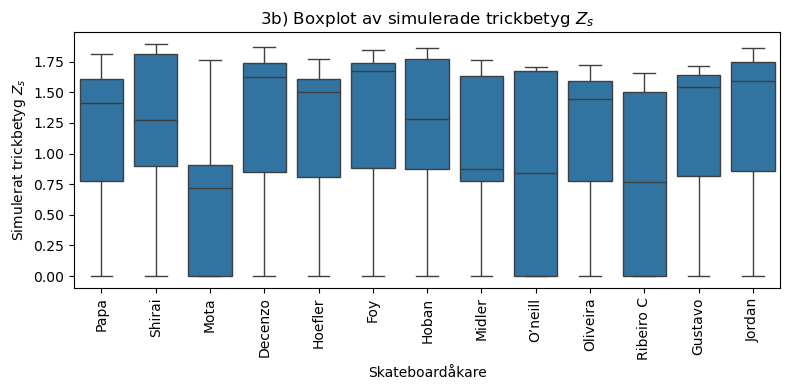

In [590]:
# 3b) Simulera Z_s och Plotta 

samples_Z = {} # Här lagras alla simulerade Z_s

# Vi hämtar rå från uppgift 1 
rho_values = rho_estimated 

for skater in rho_values.keys():
    # Simulera bara om vi har theta/tau för åkaren
    if skater in theta_values:
        rho = rho_values[skater]
        theta = theta_values[skater]
        tau = tau_values[skater] 

        Zs_samples = [] 

        for _ in range(100): # 100 simuleringar per åkare
            #Simulera om tricken lyckas 
            X = np.random.binomial(1, rho, size=4)

            #Simulera betyg T för lyckade trick )
            T = np.zeros(4)
            success_idx = np.where(X == 1)[0]
            
            if len(success_idx) > 0:
               
                T[success_idx] = np.random.normal(theta, tau, size=len(success_idx))

            # Transformera tillbaka till Z 
            Z = np.zeros(4)
            if len(success_idx) > 0:
                Z[success_idx] = g_inv(T[success_idx])

            #Summera de 2 bästa tricken
            Z_total = np.sort(Z)[-2:].sum()
            Zs_samples.append(Z_total)

        #Spara som numpy array för attt kunna plussa ihop senare
        samples_Z[skater] = np.array(Zs_samples)

#Boxplot
df_Z_plot = pd.DataFrame([
    {"id": skater, "Zs": val}
    for skater, arr in samples_Z.items()
    for val in arr
])

plt.figure(figsize=(8,4))
sns.boxplot(data=df_Z_plot, x="id", y="Zs")
plt.xticks(rotation=90)
plt.xlabel("Skateboardåkare")
plt.ylabel("Simulerat trickbetyg $Z_s$")
plt.title("3b) Boxplot av simulerade trickbetyg $Z_s$")
plt.tight_layout()
plt.show()

In [591]:
# 3c)

means_Z = [] #kommer lagra åkarens namn och deras medelvärde av Z 
#Loopa igenom ordboken samples_Z som innehåller åkarnas namn och deras simulerade värden 
for skater, values in samples_Z.items():
    mean_val = np.mean(values) #beräknar medelvrädet 
    means_Z.append([skater, mean_val])

df_means_Z = pd.DataFrame(means_Z, columns=["id", "mean_Z"]) ##får en tabellstruktur 
df_means_Z_sorted = df_means_Z.sort_values(by="mean_Z", ascending=False) ##sorterar 

print(" Resultat 3c: Trickbetyg (Z)")
print(df_means_Z_sorted.round(3))
print("\n") 

 Resultat 3c: Trickbetyg (Z)
           id  mean_Z
5         Foy   1.323
3     Decenzo   1.280
12     Jordan   1.233
1      Shirai   1.229
4     Hoefler   1.218
11    Gustavo   1.211
6       Hoban   1.207
9    Oliveira   1.128
0        Papa   1.111
7      Midler   1.070
8     O’neill   0.818
10  Ribeiro C   0.755
2        Mota   0.635




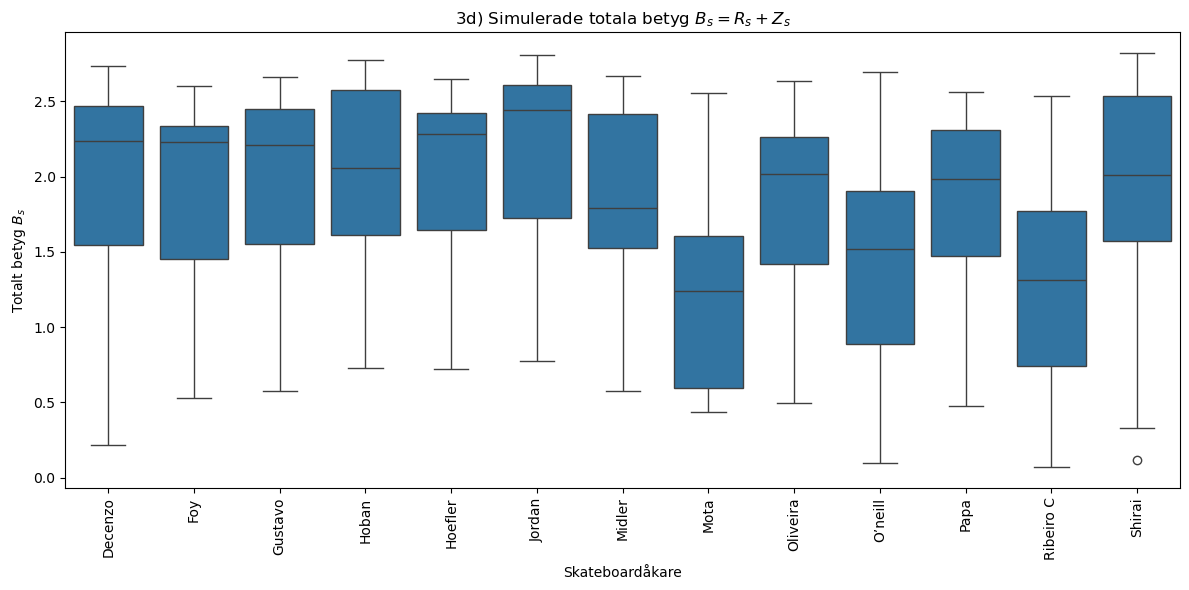

In [592]:
# 3d) 

samples_B = {} 

#
for skater in samples.keys(): 
    if skater in samples_Z:
        Rs = np.array(samples[skater]) # Run-poäng
        Zs = samples_Z[skater]         # Trick-poäng
        
        # Elementvis addition
        Bs = Rs + Zs 
        samples_B[skater] = Bs

# Boxplot
df_B_plot = pd.DataFrame([
    {"id": skater, "Bs": val}
    for skater, arr in samples_B.items()
    for val in arr
])

plt.figure(figsize=(12,6))
sns.boxplot(data=df_B_plot, x="id", y="Bs")
plt.xticks(rotation=90)
plt.xlabel("Skateboardåkare")
plt.ylabel("Totalt betyg $B_s$")
plt.title("3d) Simulerade totala betyg $B_s = R_s + Z_s$")
plt.tight_layout()
plt.show()


In [593]:
# 3e) 


means_B = []  #kommer lagra åkarens namn och deras medelvärde av B

for skater, values in samples_B.items(): #ska loopa igenom samples_B från uppgift 3d
    mean_val = np.mean(values)
    means_B.append([skater, mean_val])

df_means_B = pd.DataFrame(means_B, columns=["id", "mean_B"]) 
df_means_B_sorted = df_means_B.sort_values(by="mean_B", ascending=False) # återigen sorterar

print(" Resultat 3e:  Totalbetyg (B)")
print(df_means_B_sorted.round(3))

 Resultat 3e:  Totalbetyg (B)
           id  mean_B
5      Jordan   2.098
4     Hoefler   2.041
3       Hoban   2.007
2     Gustavo   1.971
0     Decenzo   1.964
12     Shirai   1.964
1         Foy   1.930
6      Midler   1.875
10       Papa   1.813
8    Oliveira   1.793
9     O’neill   1.439
11  Ribeiro C   1.291
7        Mota   1.226


In [594]:
## UPPGIFT 4

#4a) 


from scipy.stats import t as student_t




def g_logit(x):
    # denna hjälpfunktion omvandlar betyg mellan och 1 till hela tallinjen
   
    eps = 1e-9 # för att undvika error dvs division med 0
    x = np.clip(np.asarray(x, float), eps, 1 - eps)
    
    return np.log(x / (1 - x))

def log_prior_t(theta, df=4, loc=2.0, scale=0.3): # Denna tar logaritmen av priorfördelningen, en student-t med 4 frihetsgrader, medelvärde 2 och spridning = 2 
    
    return student_t.logpdf(theta, df=df, loc=loc, scale=scale)

def log_lik_normal(theta, t_obs, tau2_hat): # här har vi log-likelihooden för observerade data givet teta, de antas vara oberoende normalfördelade med teta som väntevärde och taU^2 med varians
    
    n = t_obs.size
    if n == 0 or tau2_hat <= 0:
        return -np.inf # om ingen data finns så defineras posteriorin av priorn
    resid2 = np.sum((t_obs - theta)**2)
    
    return -0.5 * (resid2 / tau2_hat + n * np.log(2 * np.pi * tau2_hat))

def mh_theta_posterior(t_obs, tau2_hat, n_keep=500, burnin=1000, thin=2, prop_sd=0.15, seed=123):
    #kommer göra en simpel metropolis algoritm för att då approximera posterion.
    # våra pparametrar är:   - t_obs: observerade g-transformerade trickbetyg, tau2_hat: skattad varians från 3a, n_keep: hur många posteriorprov som sparas efter burn-in, burnin: antal första iterationer som kastas bort, thin: hur ofta vi sparar (t.ex. varannan iteration), prop_sd: spridning i förslagsfördelningen N(θ, prop_sd²)
    rng = np.random.default_rng(seed)
    theta = float(np.mean(t_obs)) if t_obs.size else 2.0 
    logp = log_prior_t(theta) + log_lik_normal(theta, t_obs, tau2_hat)
    kept = []
    total = burnin + n_keep * thin
    accepts = 0

    for it in range(total):
        
        #föreslå ett nytt värde från normalfördelning runt nuvarande teta 
        prop = theta + rng.normal(0.0, prop_sd) 
        
        #sedan räkna ut posteriorivärde av förslaget
        logp_prop = log_prior_t(prop) + log_lik_normal(prop, t_obs, tau2_hat)
        
        if np.log(rng.uniform()) < (logp_prop - logp): #vi accepterar med sannolikhet min(1, exp(logp_prop - logp))
            theta, logp = prop, logp_prop
            accepts += 1
        if it >= burnin and ((it - burnin) % thin == 0):  # Efter burn-in så spara varannan iteration (thin=2)
            kept.append(theta)

    acc_rate = accepts / total
    # snabb koll: om acc_rate är ~0.2–0.6 är det ofta lagom; annars justera prop_sd
    print(f"MH acceptansgrad: {acc_rate:.2f} (n={t_obs.size} observationer)")
    
    return np.array(kept)


tau2_by_id = dict(zip(theta_tau_table["id"], theta_tau_table["tau2_hat"])) #vi hämtar skattat tau^2 från uppgift 3a


long = df.melt(id_vars="id", value_vars=trick_cols, var_name="trick", value_name="score") #smälter datan pga varje rad = (åkare, trick, betyg)

# vi tar endast med de lyckade tricken
landed = long[long["score"] > 0].copy()
landed["t_g"] = g_logit(landed["score"]) #g-tranform värden


#nu ska vi gruppera per åkare och spara deras observerade trickbetygen som arrayerr
t_by_id = landed.groupby("id")["t_g"].apply(lambda s: s.to_numpy()).to_dict()
skaters = sorted(t_by_id.keys())

# metropolis för varje åkare 
posterior_samples = {}
for sid in skaters:
    t_obs = t_by_id[sid]
    tau2 = float(tau2_by_id.get(sid, 0.02))  #om värde saknas använd ett litet standardvärde 
    posterior_samples[sid] = mh_theta_posterior(t_obs, tau2, n_keep=500, burnin=1000, thin=2, prop_sd=0.15, seed=2025)

# visar resultat
post_summ = pd.DataFrame(
    [(sid, np.mean(v), np.std(v)) for sid, v in posterior_samples.items()],
    columns=["id","theta_post_mean","theta_post_sd"]
).sort_values("theta_post_mean", ascending=False)

print(post_summ.round(3))




MH acceptansgrad: 0.75 (n=7 observationer)
MH acceptansgrad: 0.69 (n=6 observationer)
MH acceptansgrad: 0.61 (n=8 observationer)
MH acceptansgrad: 0.59 (n=8 observationer)
MH acceptansgrad: 0.71 (n=7 observationer)
MH acceptansgrad: 0.70 (n=8 observationer)
MH acceptansgrad: 0.74 (n=4 observationer)
MH acceptansgrad: 0.82 (n=3 observationer)
MH acceptansgrad: 0.65 (n=5 observationer)
MH acceptansgrad: 0.37 (n=3 observationer)
MH acceptansgrad: 0.75 (n=7 observationer)
MH acceptansgrad: 0.60 (n=3 observationer)
MH acceptansgrad: 0.75 (n=8 observationer)
           id  theta_post_mean  theta_post_sd
12     Shirai            2.215          0.198
3       Hoban            2.009          0.098
5      Jordan            1.945          0.148
1         Foy            1.844          0.145
0     Decenzo            1.771          0.191
9     O’neill            1.697          0.048
7        Mota            1.636          0.274
6      Midler            1.624          0.192
2     Gustavo            1.

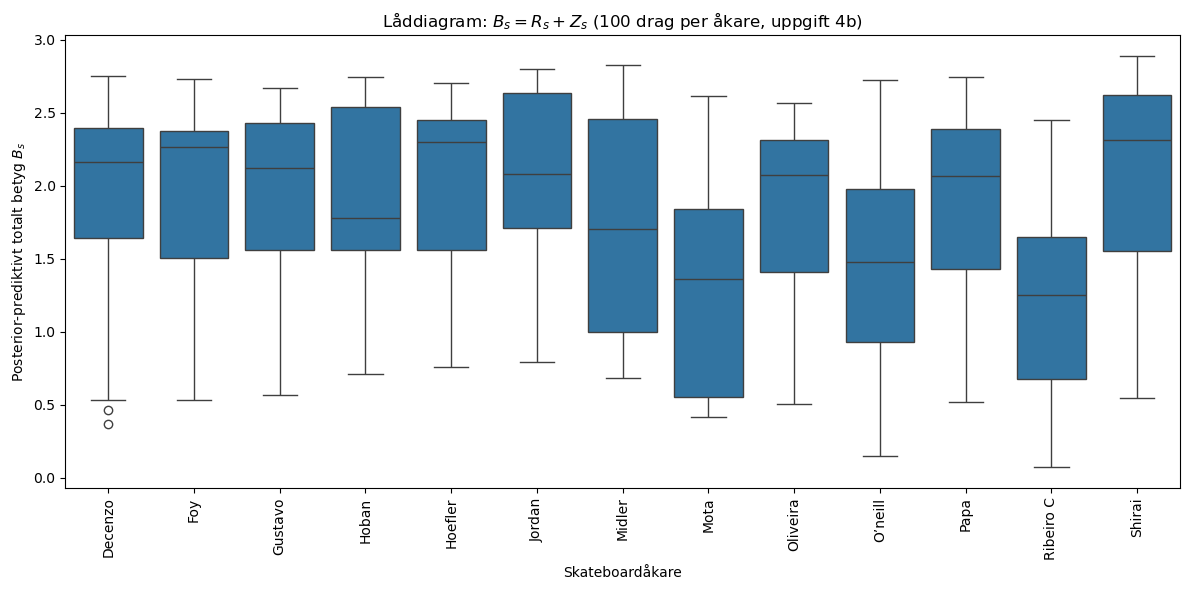

Posterior-prediktiva medel för B_s (topplista):
id
Jordan     2.069
Shirai     2.051
Foy        2.007
Decenzo    1.959
Hoefler    1.956
Hoban      1.915
Gustavo    1.900
Papa       1.845
Name: B_s, dtype: float64


In [595]:
# 4b)

# kopplar varje åkare till skattad varians tau^2
tau2_by_id = dict(zip(theta_tau_table["id"], theta_tau_table["tau2_hat"])) 


skaters = sorted(posterior_samples.keys()) # säkerstället att vi använder samma uppsättning åkare som i 4a) 


# nu kommer vi för varje åkare s simulera 100 möjligga framtida tävlingsfall enligt:
#   1) Dra teta ~ posterior(teta_s | data)
#   2) Dra fyra Bernoulli-utfall X_i ~ Ber(rho_s) (om tricket lyckas)
#   3) Om X_i = 1, dra T_i ~ N(teta, tau^2²) på g-skalan och omvandla till originalskalan med g⁻¹(T_i)
#   4) Summera de två högsta tricken: Z_s = sum(top 2)
#   5) Kombinera med run-resultatet: B_s = R_s + Z_s
 
rng = np.random.default_rng(42) 
Zs_pp = {}   # det Z_s-posteriorprediktiva trick betyg
Bs_pp = {}   #total poäng

for sid in skaters: 
    #hämtar parameter för aktuell åkare 
   
    thetas = posterior_samples[sid] # 500 st från posteriorin för teta
    rho = float(rho_estimated[sid]) # sannolikhet att landa ett trick 
    tau2 = float(tau2_by_id.get(sid, 0.02)) # varians från uppgift 3a) 
    tau = np.sqrt(max(tau2, 1e-8)) #standardavvikelse, liten nedre gräns för stabilitet

    
    Rs = np.asarray(samples[sid]) # tidigare simulerade run poäng från 2d 
    if Rs.size < 100:
        raise ValueError(f"Rs för {sid} har för få simuleringar ({Rs.size}). Generera minst 100 i uppgift 2d.")

    Z_list = [] #ska lagra 100 simulerade Z-s
    B_list = [] # lagra 100 simulerade B-s

    for k in range(100):
        
        theta_k = rng.choice(thetas) # dra ett värde från åkarens posterior 

        
        X = rng.binomial(1, rho, size=4) # ska dra 4 bernoilli utfall som avgör om tricket lyckas (binomial med n = 1 är bernoilifördelad har vi lärt oss) 

      
        Z_vals = np.zeros(4)  #Om tricket lyckas dra betyg på g-skalan och transformera till originalskalan [0,1]
        landed_idx = np.where(X == 1)[0]
        if landed_idx.size > 0:
            T = rng.normal(loc=theta_k, scale=tau, size=landed_idx.size)
            Z_vals[landed_idx] = g_inv(T) 

         
        Z_total = np.sort(Z_vals)[-2:].sum() # Z_s är summan av de två högsta tricjbetygen
        Z_list.append(Z_total)

       
        B_list.append(float(Rs[k]) + Z_total) # här summerar vi trick + run för varje simulering
        
    # spara resultat för varje åkare 
    Zs_pp[sid] = np.array(Z_list)
    Bs_pp[sid] = np.array(B_list)


df_B = pd.DataFrame( # skapar tabell i longformat för plottnign 
    [{"id": sid, "B_s": val} for sid, arr in Bs_pp.items() for val in arr]
)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_B, x="id", y="B_s")
plt.xticks(rotation=90)
plt.xlabel("Skateboardåkare")
plt.ylabel(r"Posterior-prediktivt totalt betyg $B_s$")
plt.title(r"Låddiagram: $B_s = R_s + Z_s$ (100 drag per åkare, uppgift 4b)")
plt.tight_layout()
plt.show()


# här gör jag en sammanfattande tabell över genomsnittliga trickbetyg 
mean_B = (
    df_B.groupby("id")["B_s"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)
print("Posterior-prediktiva medel för B_s (topplista):")
print(mean_B.head(8))
